<img src="../Decorative-Elements/Section-03/ADL-S03-Image-04.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/01-Simulation-of-Sun-and-Earth.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/03-Simulation-of-Planets-in-Solar-System.ipynb" target="_blank">Next</a>
</p>

In [1]:
import rebound
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

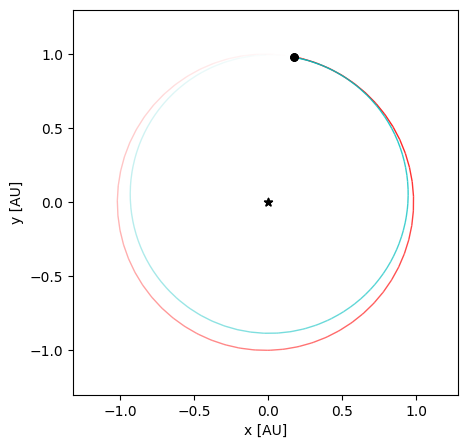

In [2]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun, Earth, Moon
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth around Sun
sim.add(m=3.7e-8, a=0.00257, e=0.0549, primary=sim.particles[1])  # Moon around Earth

sim.move_to_com()

# Compute current time since epoch
epoch = datetime(2000, 1, 1)
today = datetime.now()
days_since_epoch = (today - epoch).days + (today - epoch).seconds/86400
years_since_epoch = days_since_epoch / 365.25

# Integrate to present date
sim.integrate(years_since_epoch)

# Plot 2D orbits
rebound.OrbitPlot(sim, unitlabel="[AU]", color=True)

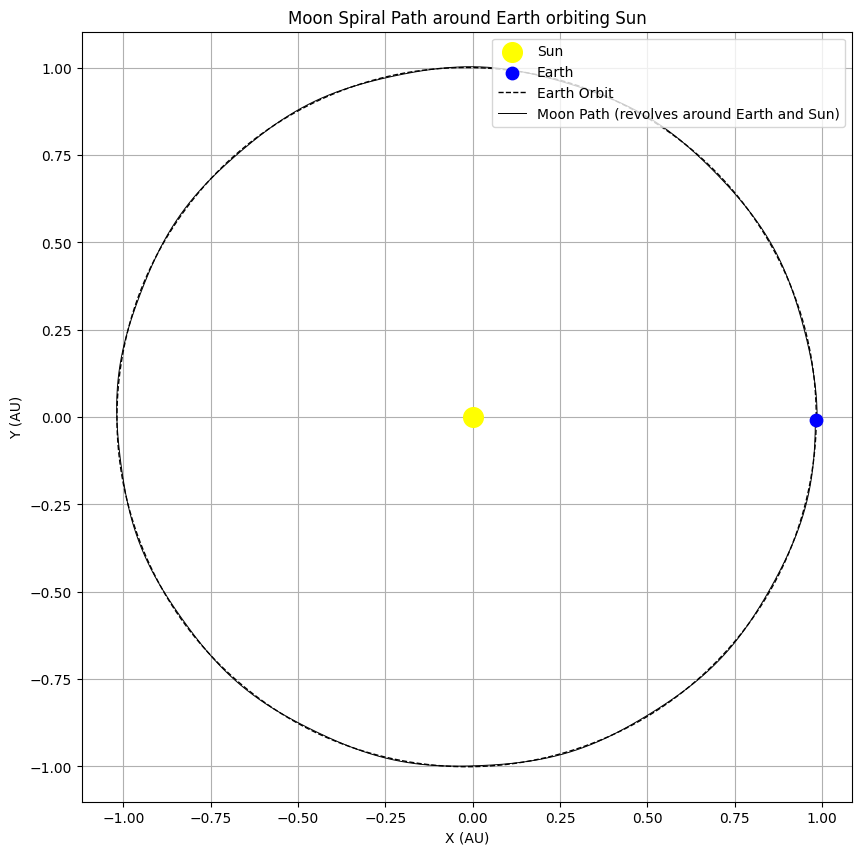

In [3]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun, Earth, Moon
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth orbiting Sun
sim.add(m=3.7e-8, a=0.00257, e=0.0549, primary=sim.particles[1])  # Moon orbiting Earth

sim.move_to_com()

# Time steps for 1 year (more steps for smooth Moon path)
N_steps = 4000
times = np.linspace(0, 1, N_steps)

moon_x = []
moon_y = []
earth_x = []
earth_y = []

for t in times:
    sim.integrate(t)
    earth = sim.particles[1]
    moon = sim.particles[2]
    
    # Absolute positions (Sun-centered)
    earth_x.append(earth.x)
    earth_y.append(earth.y)
    moon_x.append(moon.x)
    moon_y.append(moon.y)

# Plotting
plt.figure(figsize=(10,10))

# Sun
sun = sim.particles[0]
plt.scatter(sun.x, sun.y, color='yellow', s=200, label='Sun', zorder=5)

# Earth final position
plt.scatter(earth_x[-1], earth_y[-1], color='blue', s=80, label='Earth', zorder=5)

# Earth orbit (dashed black)
plt.plot(earth_x, earth_y, 'k--', linewidth=1, label='Earth Orbit')

# Moon path (thin black)
plt.plot(moon_x, moon_y, 'k-', linewidth=0.7, label='Moon Path (revolves around Earth and Sun)')

plt.title("Moon Spiral Path around Earth orbiting Sun")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.gca().set_aspect('equal')
plt.legend()
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

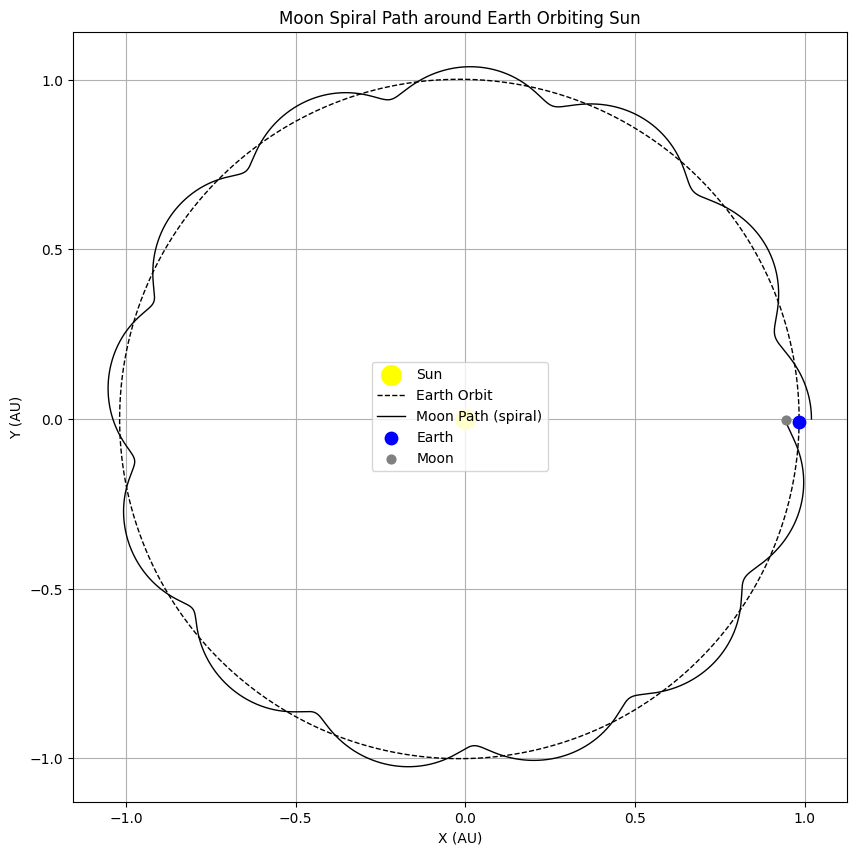

In [4]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun, Earth, Moon
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth orbiting Sun
sim.add(m=3.7e-8, a=0.00257, e=0.0549, primary=sim.particles[1])  # Moon orbiting Earth

sim.move_to_com()

# Time steps for 1 year, more steps for smooth spiral
N_steps = 5000
times = np.linspace(0, 1, N_steps)

moon_x = []
moon_y = []
earth_x = []
earth_y = []

scale_factor = 15  # scale Moon orbit for visibility

for t in times:
    sim.integrate(t)
    earth = sim.particles[1]
    moon = sim.particles[2]
    
    # Earth absolute position
    earth_x.append(earth.x)
    earth_y.append(earth.y)
    
    # Moon absolute position, scaled relative to Earth
    moon_x.append(earth.x + (moon.x - earth.x)*scale_factor)
    moon_y.append(earth.y + (moon.y - earth.y)*scale_factor)

# Plot
plt.figure(figsize=(10,10))

# Sun
plt.scatter(0,0,color='yellow',s=200,label='Sun', zorder=5)

# Earth orbit around Sun
plt.plot(earth_x, earth_y, 'k--', linewidth=1, label='Earth Orbit')

# Moon spiral path (connected loops, uniform)
plt.plot(moon_x, moon_y, 'k-', linewidth=1, label='Moon Path (spiral)')

# Earth final position
plt.scatter(earth_x[-1], earth_y[-1], color='blue', s=80, label='Earth', zorder=5)

# Moon final position
plt.scatter(moon_x[-1], moon_y[-1], color='gray', s=40, label='Moon', zorder=5)

plt.title("Moon Spiral Path around Earth Orbiting Sun")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun, Earth, Moon
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth orbiting Sun
sim.add(m=3.7e-8, a=0.00257, e=0.0549, primary=sim.particles[1])  # Moon orbiting Earth

sim.move_to_com()

# Time steps
N_steps = 2000
times = np.linspace(0, 1, N_steps)

moon_x = []
moon_y = []
moon_z = []
earth_x = []
earth_y = []
earth_z = []

scale_factor = 15  # scale Moon orbit for visibility

for t in times:
    sim.integrate(t)
    earth = sim.particles[1]
    moon = sim.particles[2]
    
    # Earth position
    earth_x.append(earth.x)
    earth_y.append(earth.y)
    earth_z.append(earth.z)
    
    # Moon position (scaled relative to Earth)
    moon_x.append(earth.x + (moon.x - earth.x)*scale_factor)
    moon_y.append(earth.y + (moon.y - earth.y)*scale_factor)
    moon_z.append(earth.z + (moon.z - earth.z)*scale_factor)

# Create 3D figure
fig = go.Figure()

# Sun
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
                           marker=dict(size=10, color='yellow'),
                           name='Sun'))

# Earth orbit
fig.add_trace(go.Scatter3d(x=earth_x, y=earth_y, z=earth_z,
                           mode='lines', line=dict(color='blue', dash='dash'),
                           name='Earth Orbit'))

# Moon spiral path
fig.add_trace(go.Scatter3d(x=moon_x, y=moon_y, z=moon_z,
                           mode='lines', line=dict(color='black', width=2),
                           name='Moon Path'))

# Earth final position
fig.add_trace(go.Scatter3d(x=[earth_x[-1]], y=[earth_y[-1]], z=[earth_z[-1]],
                           mode='markers', marker=dict(size=5, color='blue'),
                           name='Earth'))

# Moon final position
fig.add_trace(go.Scatter3d(x=[moon_x[-1]], y=[moon_y[-1]], z=[moon_z[-1]],
                           mode='markers', marker=dict(size=3, color='gray'),
                           name='Moon'))

# Layout
fig.update_layout(scene=dict(
                    xaxis_title='X (AU)',
                    yaxis_title='Y (AU)',
                    zaxis_title='Z (AU)',
                    aspectmode='data'),
                  title="3D Spiral Path of Moon around Earth orbiting Sun")

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

In [6]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun, Earth, Moon
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth around Sun
sim.add(m=3.7e-8, a=0.00257, e=0.0549, primary=sim.particles[1])  # Moon around Earth

sim.move_to_com()

# Simulation parameters
N_steps = 10000
times = np.linspace(0, 1, N_steps)  # 1 Earth year in simulation units

# Store angles
moon_angles = []
earth_angles = []

for t in times:
    sim.integrate(t)
    sun = sim.particles[0]
    earth = sim.particles[1]
    moon = sim.particles[2]

    # Moon angle around Earth
    dx_m = moon.x - earth.x
    dy_m = moon.y - earth.y
    moon_angle = np.arctan2(dy_m, dx_m)
    moon_angles.append(moon_angle)

    # Earth angle around Sun
    dx_e = earth.x - sun.x
    dy_e = earth.y - sun.y
    earth_angle = np.arctan2(dy_e, dx_e)
    earth_angles.append(earth_angle)

# Unwrap angles to remove jumps
moon_angles = np.unwrap(moon_angles)
earth_angles = np.unwrap(earth_angles)

# Total angles swept
total_moon_angle = moon_angles[-1] - moon_angles[0]
total_earth_angle = earth_angles[-1] - earth_angles[0]

# Revolutions
moon_cycles = total_moon_angle / (2 * np.pi)
earth_cycles = total_earth_angle / (2 * np.pi)

# Orbital periods in days
moon_period_days = 365.25 / moon_cycles
earth_period_days = 365.25 / earth_cycles

print(f"Earth completes ~{earth_cycles:.2f} revolutions around Sun in 1 year")
print(f"Earth orbital period: {earth_period_days:.2f} days")
print(f"Moon completes ~{moon_cycles:.2f} revolutions around Earth in 1 Earth year")
print(f"Moon orbital period: {moon_period_days:.2f} days")

Earth completes ~1.00 revolutions around Sun in 1 year
Earth orbital period: 365.80 days
Moon completes ~13.48 revolutions around Earth in 1 Earth year
Moon orbital period: 27.10 days


<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/01-Simulation-of-Sun-and-Earth.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/03-Simulation-of-Planets-in-Solar-System.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-02.gif">